
<h1 id="1.2%EF%BC%9ATime-Walk-%E6%95%88%E5%BA%94%E7%9A%84%E6%A0%A1%E5%87%86%E4%B8%8E%E4%BF%AE%E6%AD%A3">1.2：Time-Walk 效应的校准与修正</h1><h2 id="1.-%E7%9B%AE%E7%9A%84">1. 目的</h2><ol>
<li><strong>timewalk修正方法，时间刻度方法</strong>：</li>
<li><strong>掌握TTree 逐事件处理</strong></li>
</ol>
<h2 id="2.-%E5%8E%9F%E7%90%86">2. 原理</h2><h3 id="2.1-Time-Walk-%E7%9A%84%E6%95%B0%E5%AD%A6%E6%8F%8F%E8%BF%B0">2.1 Time-Walk 的数学描述</h3><p>信号幅度 $A$ 对触发时间 $t$ 的附加延迟在本例中用下式作经验描述：
$$t_{measured} = t_{true} + \frac{W}{\sqrt{A}}$$
当粒子击中长条闪烁体时，测量到的时间包含飞行时间、光传导延迟和 Walk 效应：
$$t_L = TOF + \frac{L+x}{v_{sc}} + t_{0L} + \frac{W_{L}}{\sqrt{A_L}}$$
$$t_R = TOF + \frac{L-x}{v_{sc}} + t_{0R} + \frac{W_{R}}{\sqrt{A_R}}$$</p>
<p>$t$ 与入射位置 $x$ 、TOF 以及 A 三者同时相关。</p>
<h3 id="2.2-%E5%88%87%E7%89%87%E6%B3%95">2.2 切片法</h3><p>利用两个物理约束来“冻结”无关变量：</p>
<ol>
<li><strong>利用位置切片（Position Cut）：</strong> 限制入射位置在探测器的某一位置附近（利用$\log{A_L/A_R}$）。</li>
<li><strong>利用 Gamma 射线：</strong> 选出 $\gamma$ 的事件，此时在窄位置切片内，真实 TOF 近似相同。</li>
</ol>
<ul>
<li>$ x_q = \frac{\lambda}{2}\ln \frac{A_R g_L}{A_L g_R} $</li>
</ul>
<p>在上述两个条件下，测量时间简化为：$t_{L/R} \approx \text{Constant} + \frac{W_{{L/R}}}{\sqrt{A_{L/R}}}$。</p>
<hr/>
<h3 id="2.3-%E8%A7%82%E5%AF%9F-Walk-%E6%95%88%E5%BA%94">2.3 观察 Walk 效应</h3><ul>
<li><strong>上图：</strong> Gamma 峰非常弥散，且由于 Walk 效应存在严重的长尾（低能端延迟更大）。</li>
<li><strong>下图：</strong> <code>tL</code> 随 <code>1/sqrt(AL)</code> 呈现弥散的带状。由于位置 $x$ 的存在，数据点分布在一个很宽的范围内，无法直接看到清晰的直线。</li>
</ul>


In [ ]:
TCanvas *c1 = new TCanvas;
TFile *f = new TFile("tree_hw_demo.root");
TTree *tree = (TTree*)f->Get("tree");

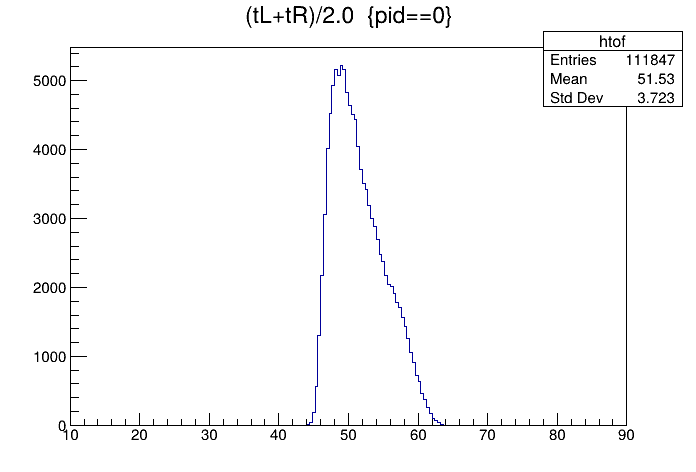

In [3]:
tree->Draw("(tL+tR)/2.0 >> htof(200, 10, 90)", "pid==0");
c1->Draw();

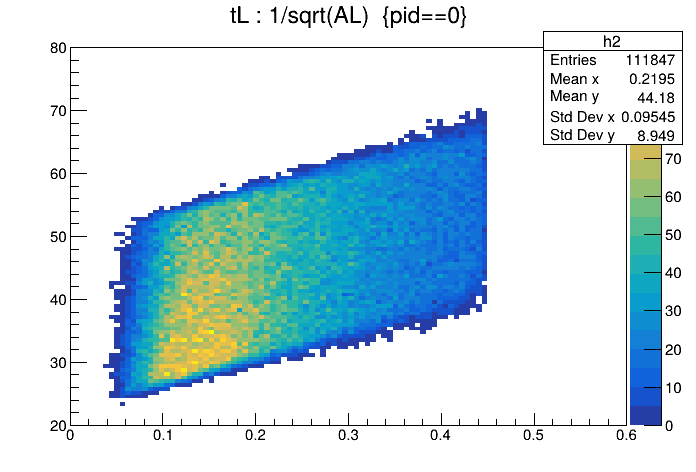

In [4]:
tree->Draw("tL : 1/sqrt(AL) >> h2(100,0,0.6, 100, 20, 80)", "pid==0", "colz");
c1->Draw();


<h2 id="3.-%E5%88%87%E7%89%87%E6%B3%95-%E6%8F%90%E5%8F%96walk%E7%B3%BB%E6%95%B0-$W_L,-W_R$">3. 切片法 提取walk系数 $W_L, W_R$</h2>


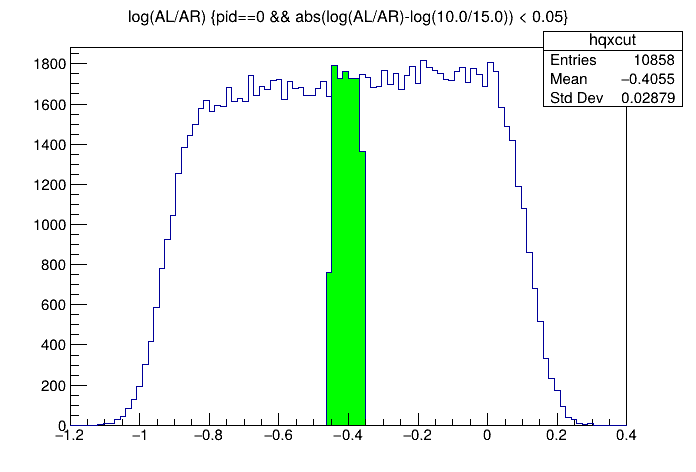

In [6]:
TCut center_cut = "pid==0 && abs(log(AL/AR)-log(10.0/15.0)) < 0.05";
tree->Draw("log(AL/AR)>>hqxcut(100,-1.2,0.4)", center_cut, "");
((TH1F*)gPad->GetPrimitive("hqxcut"))->SetFillColor(kGreen);
tree->Draw("log(AL/AR)>>hqx(100,-1.2,0.4)", "pid==0", "same");
c1->Draw();


<h3 id="3.1-gamma-%E6%89%93%E5%9C%A8%E5%9B%BA%E5%AE%9A%E4%BD%8D%E7%BD%AE%E6%97%B6-t%EF%BD%9E-1/$%5Csqrt(A)$%E7%9A%84%E5%85%B3%E7%B3%BB">3.1 gamma 打在固定位置时 t～ 1/$\sqrt(A)$的关系</h3><ul>
<li>将两端的 $t : 1/\sqrt{A}$ 二维图保存到TProfile，利用线性方程 $Y = W_A \cdot X + C$ 拟合，得到walk系数 $W_A$。</li>
<li>可以把探测器切成多个独立的“切片（Slices）”，对每一个切片分别拟合求出斜率，最后用加权平均合并结果，从而利用更高统计量，以减少$W_A $的误差。</li>
</ul>
<h4 id="Left">Left</h4>
<p>TProfile 直接保存每个横轴 bin 内的事件平均时间及其误差，拟合斜率给出 W。左图用 TH2 显示分布，右图用相同事件直接填充 TProfile，避免把纵轴 bin 中心当作原始时间。位置切片有有限宽度，幅度比也有噪声，因此这是近似校准，可比较不同切片的结果。示例中的 pid 用于展示已知粒子的响应，作业改用图形选择。</p><p>拟合使用 Profile 的均值和均值误差。只有一个事件的 bin 无法从样本估计方差，故不把它作为加权拟合点；它仍保留在原始二维图和 Profile 中。下面用 TGraphErrors 明确列出参与拟合的均值点。</p>

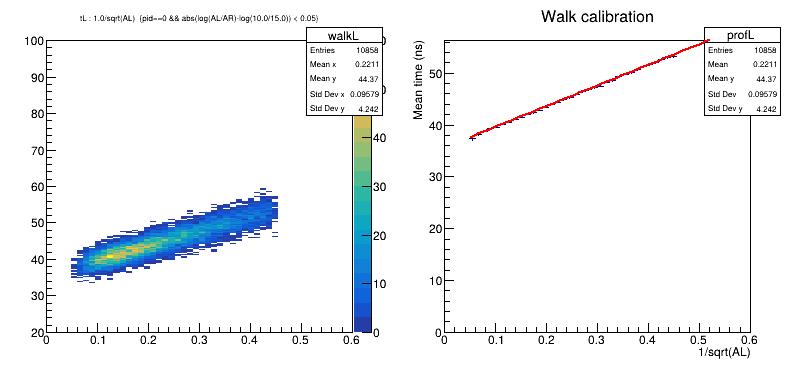

In [8]:
TF1 *fFit = new TF1("fFit", "pol1", 0.05, 0.6); 

TCanvas *c2 = new TCanvas("c2", "Calibration", 800, 400);
c2->Clear();
c2->Divide(2,1);
c2->cd(1);
tree->Draw("tL : 1.0/sqrt(AL) >> walkL(50,0,0.6,240,20,100)", center_cut, "colz");
c2->cd(2);
TProfile *profL = new TProfile("profL","Walk calibration;1/sqrt(AL);Mean time (ns)",50,0,0.6);
tree->Draw("tL:1/sqrt(AL)>>profL", center_cut, "prof");
TGraphErrors *meansL = new TGraphErrors;
for (int b=1; b<=profL->GetNbinsX(); ++b) {
    // 单个事件不能估计该 bin 的时间方差，因此不作为拟合点。
    if (profL->GetBinEntries(b)<2 || profL->GetBinError(b)<=0) continue;
    int n = meansL->GetN();
    meansL->SetPoint(n, profL->GetBinCenter(b), profL->GetBinContent(b));
    meansL->SetPointError(n, 0, profL->GetBinError(b));
}
meansL->Fit(fFit, "RQ");
fFit->Draw("same");
c2->Draw();
Double_t WL = fFit->GetParameter(1);
Double_t err_WL = fFit->GetParError(1);
Double_t CL = fFit->GetParameter(0);


<h4 id="Right">Right</h4>


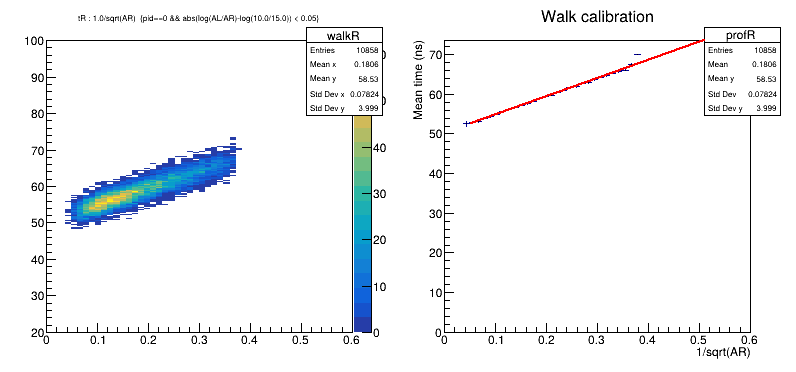

In [10]:
c2->Clear();
c2->Divide(2,1);
c2->cd(1);
tree->Draw("tR : 1.0/sqrt(AR) >> walkR(50,0,0.6,240,20,100)", center_cut, "colz");
c2->cd(2);
TProfile *profR = new TProfile("profR","Walk calibration;1/sqrt(AR);Mean time (ns)",50,0,0.6);
tree->Draw("tR:1/sqrt(AR)>>profR", center_cut, "prof");
TGraphErrors *meansR = new TGraphErrors;
for (int b=1; b<=profR->GetNbinsX(); ++b) {
    // 单个事件不能估计该 bin 的时间方差，因此不作为拟合点。
    if (profR->GetBinEntries(b)<2 || profR->GetBinError(b)<=0) continue;
    int n = meansR->GetN();
    meansR->SetPoint(n, profR->GetBinCenter(b), profR->GetBinContent(b));
    meansR->SetPointError(n, 0, profR->GetBinError(b));
}
meansR->Fit(fFit, "RQ");
fFit->Draw("same");
c2->Draw();
Double_t WR = fFit->GetParameter(1);
Double_t err_WR = fFit->GetParError(1);
Double_t CR = fFit->GetParameter(0);

In [11]:
std::cout << Form(">>> 提取参数: WL=%.2f ± %.2f | WR=%.2f ± %.2f", WL, err_WL, WR, err_WR) << std::endl;

>>> 提取参数: WL=39.85 ± 0.19 | WR=45.49 ± 0.23


<h2 id="3.-%E5%BA%94%E7%94%A8%E4%BF%AE%E6%AD%A3">3. 应用修正</h2><h3 id="3.1-Walk%E7%B3%BB%E6%95%B0%E4%BF%AE%E6%AD%A3">3.1 Walk系数修正</h3><ul>
<li><strong>蓝色峰：</strong>  修正前</li>
<li><strong>红色峰（修正后）：</strong> 峰宽显著变窄，形状接近对称的高斯分布。</li>
</ul>


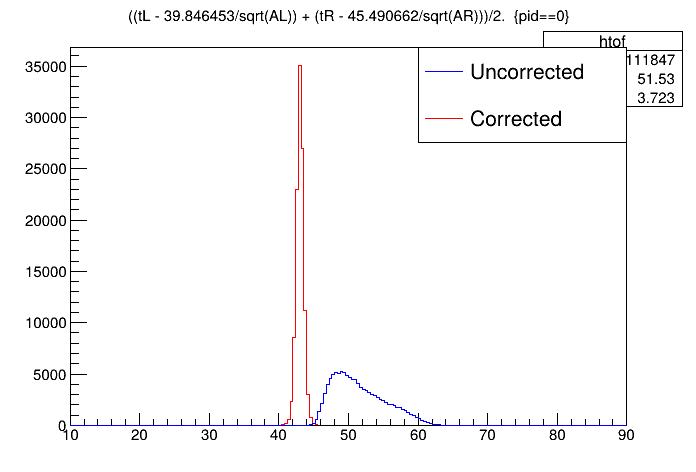

In [13]:
TCanvas *c3 = new TCanvas("c3", "Verification");
tree->SetLineColor(kBlue);
// 定义 Walk 修正后的时间
TString tL_corr = Form("(tL - %f/sqrt(AL))", WL);//"tL-45.2/sqrt(AL)"
TString tR_corr = Form("(tR - %f/sqrt(AR))", WR);
TString tof = Form("(%s + %s)/2.", tL_corr.Data(),tR_corr.Data());
TString tx = Form("(%s - %s)/2.", tL_corr.Data(),tR_corr.Data());

TString draw_tof = Form("%s >> h_new(200,10,90)", tof.Data());
tree->SetLineColor(kRed);
tree->Draw(draw_tof, "pid==0", "");

htof->SetLineColor(kBlue);
htof->Draw("same");

TLegend *leg = new TLegend(0.6, 0.7, 0.9, 0.9);
leg->AddEntry("htof", "Uncorrected", "l");
leg->AddEntry("h_new", "Corrected", "l");
leg->Draw();

c3->Draw();


<h3 id="3.2-%E6%97%B6%E9%97%B4%E5%81%8F%E7%A7%BB%E4%BF%AE%E6%AD%A3">3.2 时间偏移修正</h3><p>在完成 Time-Walk 修正后，获得了反映粒子入射位置的已扣除主要 walk 的时间差信息。本节的目标是确定时间差与物理空间坐标 $x$ 的映射关系。</p>
<h4 id="3.2.1-%E5%88%A9%E7%94%A8%E5%BE%AE%E5%88%86%E6%B3%95%E8%BF%9B%E8%A1%8C%E4%BD%8D%E7%BD%AE%E5%88%BB%E5%BA%A6">3.2.1 利用微分法进行位置刻度</h4><p>探测器位置x与两侧时间差(修正后)之间有如下关系：</p>
<p>$$
 x_{t} = \frac{v_{sc}}{2} (t_L - t_R - (t_{0L}-t_{0R}))
$$</p>
<ul>
<li>通过下列步骤得到刻度系数：$v_{sc}/{2}$ 和 $t_{0L}-t_{0R}$.</li>
</ul>
<p><strong>1. 物理思想：寻找“消失的边缘”</strong>
由于探测器在空间上是有限的（长度为 $2L$），当粒子均匀入射时，时间差 $\Delta t = (t_L - t_R)$ 的分布理论上是一个矩形。但由于时间分辨率的存在，计数的分布在边缘处并非垂直下降，而是带有高斯卷积的阶梯。因此，可用导数极值定位边缘，也可直接拟合展宽后的阶梯形状。</p>
<img alt="Image" height="80%" src="fig/tdiff.png" width="80%"/>
<ul>
<li>建立时间差的直方图(TH1) $h1$</li>
</ul>
<ul>
<li><p><strong>微分法的逻辑</strong>：对 $h1$ 分布求导（数值微分），计数下降最快的地方（导数的极值点）即对应探测器的物理边界。</p>
</li>
<li><p><strong>刻度目标</strong>：识别左边界 $\Delta t_{left}$ 和右边界 $\Delta t_{right}$，建立线性映射：$x = k \cdot \Delta t + b$，使两处边缘的中心映射到 −L 和 L；分辨会使少量重建值落在边界外。</p>
</li>
<li><p><strong>获取 X 轴的 Bin 总数</strong>（不含 Underflow 和 Overflow）：</p>
<div class="highlight"><pre><span></span><span class="n">Int_t</span><span class="w"> </span><span class="n">nBins</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="n">h1</span><span class="o">-&gt;</span><span class="n">GetNbinsX</span><span class="p">();</span>
</pre></div>
<p><em>注：ROOT 的直方图索引从 <code>1</code> 到 <code>nBins</code>。<code>0</code> 号 Bin 是 Underflow（低于范围），<code>nBins+1</code> 号 Bin 是 Overflow（高于范围）。</em></p>
</li>
<li><p><strong>在循环中遍历所有 Bin</strong>：</p>
<div class="highlight"><pre><span></span><span class="k">for</span><span class="w"> </span><span class="p">(</span><span class="kt">int</span><span class="w"> </span><span class="n">i</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="mi">1</span><span class="p">;</span><span class="w"> </span><span class="n">i</span><span class="w"> </span><span class="o">&lt;=</span><span class="w"> </span><span class="n">h1</span><span class="o">-&gt;</span><span class="n">GetNbinsX</span><span class="p">();</span><span class="w"> </span><span class="n">i</span><span class="o">++</span><span class="p">)</span><span class="w"> </span><span class="p">{</span>
<span class="w">    </span><span class="n">Double_t</span><span class="w"> </span><span class="n">content</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="n">h1</span><span class="o">-&gt;</span><span class="n">GetBinContent</span><span class="p">(</span><span class="n">i</span><span class="p">);</span>
<span class="w">    </span><span class="c1">// ... 处理代码</span>
<span class="p">}</span>
</pre></div>
<ul>
<li><p><strong>数值微分</strong>：最简单的实现是 <code>diff = h1-&gt;GetBinContent(i+1) - h1-&gt;GetBinContent(i)</code>，将微分结果存入一个新的直方图。</p>
</li>
<li><p><strong>寻找“向下的峰”</strong>：在右边缘，导数是负的（计数在减少）。当你使用 <code>gaus</code> 拟合这个负峰时，<strong>必须手动给定初值</strong>，否则拟合会失败：
, 需设定拟合参数的合理初值。</p>
<div class="highlight"><pre><span></span><span class="n">TF1</span><span class="w"> </span><span class="o">*</span><span class="n">f1</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="k">new</span><span class="w"> </span><span class="n">TF1</span><span class="p">(</span><span class="s">"f1"</span><span class="p">,</span><span class="s">"[0]*TMath::Exp(-0.5*((x-[1])/[2])^2)"</span><span class="p">,</span><span class="n">xbin1</span><span class="p">,</span><span class="n">xbin2</span><span class="p">);</span><span class="c1">//定义函数的方法 TF1</span>
<span class="c1">//gaus:f(x) = p0*exp(-0.5*((x-p1)/p2)^2)</span>
<span class="n">f1</span><span class="o">-&gt;</span><span class="n">SetParameters</span><span class="p">(</span><span class="o">-</span><span class="n">A0_guess</span><span class="p">,</span><span class="w"> </span><span class="n">x_guess</span><span class="p">,</span><span class="w"> </span><span class="n">sigma_guess</span><span class="p">);</span><span class="w"> </span><span class="c1">// 振幅设为负(-A0_guess)，给定位置初值(x_guess)和宽度初值(sigma_guess)</span>
</pre></div>
</li>
</ul>
</li>
</ul>
<p>有限差分应止于最后一个相邻的普通 bin，不把 overflow 混入。邻近差分共享计数，彼此相关；用导数图定位边缘时，不宜把各点简单当作独立计数来求精确误差。</p>


<h4 id="3.2.3-%E4%BD%8D%E7%BD%AE%E9%87%8D%E5%BB%BA%E9%AA%8C%E8%AF%81">3.2.3 位置重建验证</h4><p>在完成 Time-Walk 修正后，获得了反映粒子入射位置的已扣除主要 walk 的时间差信息。</p>
<ul>
<li><p><strong>物理公式：</strong> 利用两侧光传导的时间差重建位置：
$$x = \frac{V_{sc}}{2} \cdot \left( (t_{L,corr} - t_{R,corr}) - \Delta t_{0} \right)$$
其中，$\Delta t_{0}$ 是通过微分法或几何中心确定的时间偏移。</p>
</li>
<li><p><strong>飞行路径：</strong> 对于距离靶心垂直距离为 $D$ 的探测器，打在位置 $x$ 处的事件，其理论飞行距离为 $z = \sqrt{D^2 + x^2}$。</p>
</li>
</ul>
<p>下面的分析直接采用分析代码中的参数设定：</p>
<div class="highlight"><pre><code class="language-cpp">const Double_t Vsc = 0.075; // m/ns
    const Double_t t0L_t0R = 5.5 - 20.4;   //ns</code></pre></div>
<ul>
<li><strong>图像分析（左图）：</strong> 绘制重建后的位置 $x$ 的一维分布。可以看到在 $[-1.0, 1.0]$ 米范围内，计数分布接近平直的矩形。这说明探测器对均匀入射的粒子具有良好的空间响应，且物理边界（条长 2m）在刻度后得到了正确还原。</li>
<li><strong>图像分析（右图）：</strong> 绘制单位距离的 TOF（<code>tof/z</code>）随位置 $x$ 的二维关联图。此时尚未进行绝对时间校准，可以看到 $\gamma$ 射线带（$pid==0$）分布在 $y \approx 8.5$ ns/m 附近。数值不对，而且进行飞行距离归一化的tof与 $x$ 存在依赖关系，说明tof还需进一步修正。</li>
</ul>


In [ ]:
const Double_t D = 5.0;      // m, 靶到探测器距离
const Double_t L = 1.0;      // m, 探测器半长
const Double_t Vsc = 0.075;  // m/ns
const Double_t t0L_t0R = 5.5 - 20.4;    //ns  

//TString tof = Form("(%s + %s)/2.", tL_corr.Data(),tR_corr.Data());
//TString tx = Form("(%s - %s)/2.", tL_corr.Data(),tR_corr.Data());

TString x = Form("%f * ((%s - %s) - %f)/2.", Vsc, tL_corr.Data(), tR_corr.Data(), t0L_t0R);
TString z = Form("sqrt(pow(%f,2) + pow(%s,2))", D, x.Data());
TString tof_norm = Form("%s / %s", tof.Data(), z.Data());
TString draw_x_tof_norm = Form("%s:%s >> htofx(100,-1,1, 100,7,10)", tof_norm.Data(), x.Data());

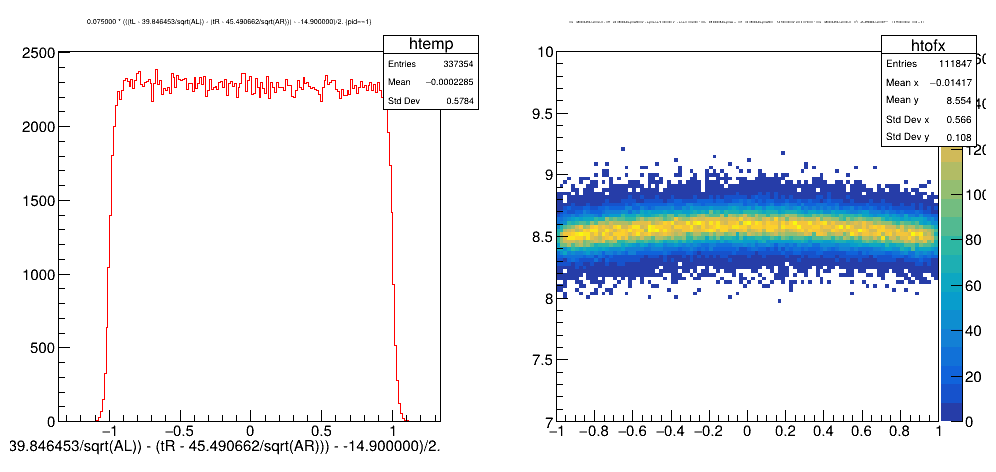

In [17]:
TCanvas *c4 = new TCanvas("c4", "Calibrate", 1000, 500);
c4->Divide(2,1);
c4->cd(1);
tree->Draw(x, "pid==1", "colz");
c4->cd(2);
tree->Draw(draw_x_tof_norm, "pid==0 ", "colz");
c4->Draw();


<h3 id="3.3-TOF%E5%88%BB%E5%BA%A6">3.3 TOF刻度</h3><p>位置刻度完成后，由于电子学系统的固有延迟（如电缆长度、触发延迟），测量到的 $TOF$ 并非绝对物理时间。</p>
<p>$$ \text{TOF}_{rec} = \frac{t_L + t_R}{2} + c_{tof}$$</p>
<ul>
<li>$c_{tof} = -L/v_{sc} - (t_{0L}+t_{0R})/2$ 为待求刻度系数。</li>
</ul>
<p><strong>校准原理：</strong> $\gamma$ 射线以光速 $c$ 飞行。已知靶心到入射点的几何距离为 $z$，则理论飞行时间应为 $z/c$（约 $3.33 \times z$ ns）。测量值与理论值的差值即为全局时间偏移（Time Offset）。
$$
TOF_{\gamma}= 3.33 * z
$$</p>
<p>$$
c_{tof} = 3.33*z  - \frac{t_L + t_R}{2}
$$</p>
<ul>
<li><strong>左图：</strong>对几何飞行时间减去已扣除 walk 的平均时间作图，拟合中心值作为时间偏移；数值见代码输出。</li>
<li><strong>图像分析（右图）：</strong> 应用偏移修正,归一化 $TOF$（$ns/m$）随位置 $x$ 的变化: 可以看到 $\gamma$ 射线带现在位于在 $3.33$ ns/m 线上，且不再随位置 $x$ 发生倾斜或弯曲。</li>
</ul>


time offset of tof = -26.2583 +/- 0.00151439 ns

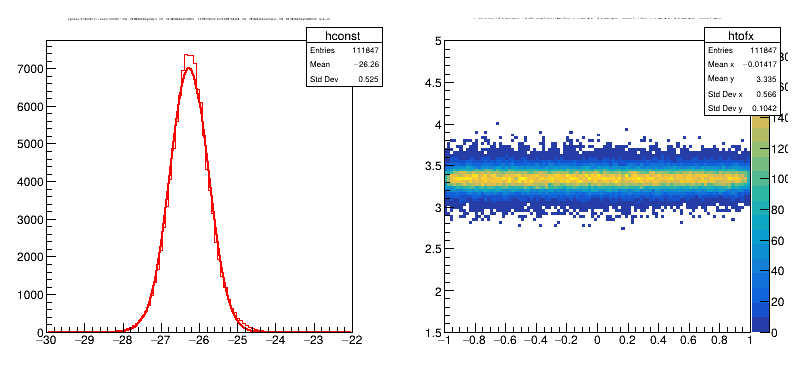

In [19]:
TString c_tof = Form("%s/0.299792458 - %s >> hconst(100, -30, -22)", z.Data(),tof.Data());
TCanvas *c5 = new TCanvas("c5", "tof Calibration", 800, 400);
c5->Divide(2,1);
c5->cd(1);
tree->Draw(c_tof,"pid==0");
TH1F *hconst = (TH1F*)gROOT->FindObject("hconst");
hconst->Fit("gaus","Q");
TF1 *fitFunc = hconst->GetFunction("gaus");
double mean = fitFunc->GetParameter(1);
cout << "time offset of tof = " << mean << " +/- " << fitFunc->GetParError(1) << " ns" << endl;

c5->cd(2);
TString tof_norm_corr = Form("(%s+%f)/%s", tof.Data(), mean, z.Data());
TString draw_x_tof_norm_corr = Form("%s:%s >> htofx(100,-1,1,100,1.5,5)", tof_norm_corr.Data(), x.Data());
tree->Draw(draw_x_tof_norm_corr, "pid==0 ", "colz");
c5->Draw();

<h3>3.4 TOF 刻度验证</h3><p>左图蓝色为模拟真值，红色为重建后按估计路径归一化的 TOF。gamma 真值位于 \(1/c=3.33564\) ns/m，重建分布还含时间涨落、位置误差和未知反应深度的影响；不能把红色峰宽直接等同于单端时间分辨。中子速度较小，分布位于更长 TOF 处。</p><p>右图用两端幅度的几何平均观察 TOF—幅度关联。</p>

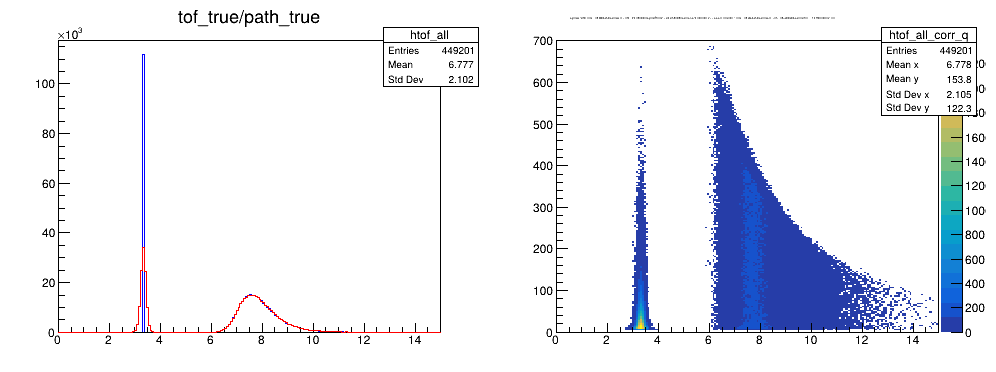

In [21]:
TCanvas *c6 = new TCanvas("tof","tof",1000,400);
c6->Divide(2,1);
c6->cd(1);
tree->Draw("tof_true/path_true>>htof_all(200,0,15)","","");
TH1F *htof_all =(TH1F*) gROOT->FindObject("htof_all");
htof_all->SetLineColor(kBlue);

TString draw_tof_corr = Form("%s>>htof_all_corr(200,0,15)",tof_norm_corr.Data());
tree->Draw(draw_tof_corr,"","same");

c6->cd(2);
TString draw_tof_corr_q = Form("sqrt(AL*AR):%s>>htof_all_corr_q(200,0,15,200,0,700)",tof_norm_corr.Data());
tree->Draw(draw_tof_corr_q,"","colz");
c6->Draw();

<h2>4. TTree 的逐事件读取与二次存储</h2><p><code>SetBranchAddress</code> 将已有分支绑定到同类型变量；<code>GetEntry(i)</code> 读取第 i 个事件的活动分支。需要只读部分分支时，再用 <code>SetBranchStatus</code> 设置。</p><h3>示例：Analyze.C</h3><p>把前面拟合得到的 WL、WR 和 TOF offset 传给事件循环。这里的几何与增益取模拟设定，作业中再从数据确定。CloneTree(0) 先复制结构，Fill 时同时保存原量和新增物理量。</p><pre><code class="language-cpp">#include &lt;TFile.h&gt;
#include &lt;TTree.h&gt;
#include &lt;cmath&gt;
#include &lt;iostream&gt;
void Analyze(double WL, double WR, double timeOffset) {
    TFile input("tree_hw_demo.root");
    TTree *tin = input.Get&lt;TTree&gt;("tree");
    double AL, AR, tL, tR;
    tin-&gt;SetBranchAddress("AL", &amp;AL);
    tin-&gt;SetBranchAddress("AR", &amp;AR);
    tin-&gt;SetBranchAddress("tL", &amp;tL);
    tin-&gt;SetBranchAddress("tR", &amp;tR);

    TFile output("calibrated.root", "RECREATE");
    TTree *tout = tin-&gt;CloneTree(0); // 保留原有分支，只复制结构
    double xt, xq, tof_cal;
    Long64_t entry;
    tout-&gt;Branch("source_entry", &amp;entry, "source_entry/L");
    tout-&gt;Branch("xt", &amp;xt, "xt/D");
    tout-&gt;Branch("xq", &amp;xq, "xq/D");
    tout-&gt;Branch("tof_cal", &amp;tof_cal, "tof_cal/D");
    for (entry=0; entry&lt;tin-&gt;GetEntries(); ++entry) {
        tin-&gt;GetEntry(entry);
        if (AL&lt;=0 || AR&lt;=0) continue;
        double tl = tL-WL/std::sqrt(AL);
        double tr = tR-WR/std::sqrt(AR);
        xt = 0.075/2 * (tl-tr-(5.5-20.4)); // m
        xq = 3.8/2 * std::log(AR*10/(AL*15)); // m
        tof_cal = (tl+tr)/2 + timeOffset; // ns
        tout-&gt;Fill();
    }
    std::cout &lt;&lt; "Input=" &lt;&lt; tin-&gt;GetEntries() &lt;&lt; ", output=" &lt;&lt; tout-&gt;GetEntries() &lt;&lt; '\n';
    tout-&gt;Write();
}</code></pre><p>载入后调用 <code>Analyze(WL, WR, mean)</code>。原始输入不修改，结果另存为 calibrated.root。</p>

<h2 id="assignment">作业</h2><ol><li>在 TOF—幅度图上选择 gamma 和中子区域，保存并应用 TCutG，不使用 pid 作分析条件。</li><li>比较多个位置切片的 walk 系数及误差，修正两端时间。用探测器边缘确定位置刻度，与模拟设定比较。</li><li>从两端幅度比求增益比与衰减长度，比较时间差位置和电荷比位置。改变相对电荷分辨，观察两种位置估计的变化。</li><li>用 gamma 峰完成 TOF 绝对刻度。按估计路径归一到 1 m，再由 \(\beta=d/(ct)\)、\(E_n=(1/\sqrt{1-\beta^2}-1)m_nc^2\) 求中子动能，与真值比较。将原始量和新增的时间、位置、TOF、能量逐事件保存到新树中。</li></ol><p>重建时只使用测量量；真值用于最后核验。几何路径的单位为 m，时间为 ns，能量为 MeV。</p>

In [24]:
gROOT->ProcessLine(".L Analyze.C");
Analyze(WL, WR, mean);

Input=449201, output=449201